In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter


#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title'] == 'Data Analyst')].copy()

df_DA_US = df_DA_US.dropna(subset='salary_year_avg')

In [3]:
df_DA_exploded= df_DA_US.explode('job_skills')

df_DA_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
1681,111175.0,sql
1681,111175.0,tableau
1681,111175.0,power bi
1681,111175.0,excel
3237,120000.0,sql


In [4]:
df_DA_skills = df_DA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count',ascending=False)

df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'}, inplace=True)

da_job_count = len(df_DA_US)

df_DA_skills['skill_percentage'] = (df_DA_skills['skill_count'] / da_job_count) * 100

skill_percent = 6

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percentage'] >  skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,714,87500.0,63.864043
excel,472,77500.0,42.218247
python,408,90000.0,36.493739
tableau,398,90000.0,35.599284
power bi,279,87500.0,24.955277
r,244,90000.0,21.824687
sas,200,84078.5,17.889088
powerpoint,102,77500.0,9.123435
word,89,75000.0,7.960644


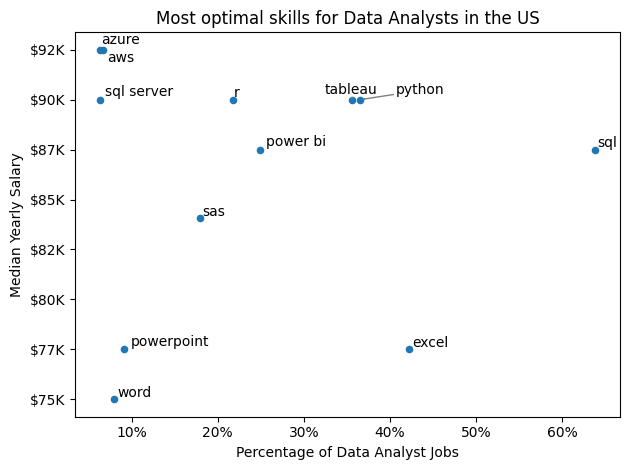

In [5]:


df_DA_skills_high_demand.plot(kind='scatter', x='skill_percentage', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most optimal skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
# Adjust layout and display plot 
plt.tight_layout()
plt.show()

In [6]:
df_technology = df['job_type_skills'].dropna().unique()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        technology_dict.setdefault(key, set()).update(value)
        
technology_dict = {k: list(v) for k, v in technology_dict.items()}

technology_dict

{'analyst_tools': ['spss',
  'tableau',
  'dax',
  'ssis',
  'sharepoint',
  'outlook',
  'ssrs',
  'spreadsheet',
  'cognos',
  'word',
  'sap',
  'datarobot',
  'esquisse',
  'powerpoint',
  'microstrategy',
  'ms access',
  'excel',
  'powerbi',
  'msaccess',
  'visio',
  'looker',
  'sas',
  'power bi',
  'qlik',
  'splunk',
  'sheets',
  'alteryx',
  'nuix'],
 'programming': ['nosql',
  'powershell',
  'sql',
  'c#',
  'vb.net',
  'bash',
  'golang',
  'elixir',
  'java',
  'css',
  'julia',
  'rust',
  'dart',
  'assembly',
  'matlab',
  'c',
  'apl',
  'f#',
  'haskell',
  'visualbasic',
  'crystal',
  'solidity',
  'erlang',
  'shell',
  'perl',
  'objective-c',
  'python',
  'fortran',
  'vba',
  'sass',
  'c++',
  'mongo',
  'typescript',
  'groovy',
  'kotlin',
  'no-sql',
  'clojure',
  'html',
  'pascal',
  'cobol',
  'lisp',
  'javascript',
  'sas',
  'ruby',
  'delphi',
  'r',
  'lua',
  'scala',
  'php',
  't-sql',
  'swift',
  'ocaml',
  'go',
  'visual basic',
  'mong

In [7]:
df_tech_view = pd.DataFrame(list(technology_dict.items()), columns=['Technology', 'Skills'])

df_tech_view = df_tech_view.explode('Skills')

df_tech_view

,Technology,Skills
0,analyst_tools,spss
0,analyst_tools,tableau
0,analyst_tools,dax
0,analyst_tools,ssis
0,analyst_tools,sharepoint
...,...,...
9,sync,rocketchat
9,sync,twilio
9,sync,microsoft teams
9,sync,symphony


In [8]:
df_DA_skills_high_demand_index = df_DA_skills_high_demand.reset_index()

df_merged = df_DA_skills_high_demand_index.merge(df_tech_view, left_on='job_skills', right_on='Skills').drop(columns=['job_skills'])

df_merged

,skill_count,median_salary,skill_percentage,Technology,Skills
0,714,87500.0,63.864043,programming,sql
1,472,77500.0,42.218247,analyst_tools,excel
2,408,90000.0,36.493739,programming,python
3,398,90000.0,35.599284,analyst_tools,tableau
4,279,87500.0,24.955277,analyst_tools,power bi
5,244,90000.0,21.824687,programming,r
6,200,84078.5,17.889088,analyst_tools,sas
7,200,84078.5,17.889088,programming,sas
8,102,77500.0,9.123435,analyst_tools,powerpoint
9,89,75000.0,7.960644,analyst_tools,word


6 [-0.72862524 -0.39895794]
7 [ 0.60760773 -0.97839251]


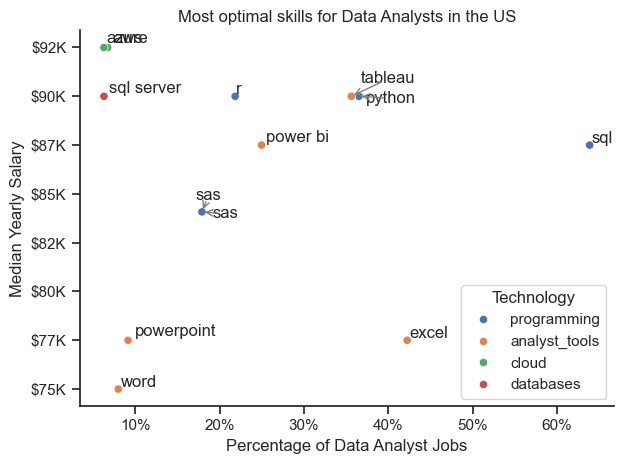

In [24]:

sns.scatterplot(data=df_merged, x='skill_percentage', y='median_salary', hue='Technology')
sns.despine()
sns.set_theme(style='ticks')


# Prepare texts for adjustText
texts = []
for i in range(len(df_merged)):
    texts.append(plt.text(
        df_merged['skill_percentage'].iloc[i], 
        df_merged['median_salary'].iloc[i], 
        df_merged['Skills'].iloc[i]  # Usamos la columna job_skills
    ))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1, shrinkA=5, relpos=(0.5, 0.5)),
            expand_points=(1.5, 1.5), # Empuja el texto lejos del punto
            force_points=0.1 )         # Evita que el texto tape el círculo)

# Set axis labels, title, and legend
plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most optimal skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
# Adjust layout and display merdf_merged 
plt.tight_layout()
plt.show()